<a href="https://colab.research.google.com/github/Payal2330/data_science_lab_75/blob/main/pr_8th.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Merged Dataset Preview:
   userId  movieId  rating  timestamp                        title  \
0       1        1     4.0  964982703             Toy Story (1995)   
1       1        3     4.0  964981247      Grumpier Old Men (1995)   
2       1        6     4.0  964982224                  Heat (1995)   
3       1       47     5.0  964983815  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0  964982931   Usual Suspects, The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  


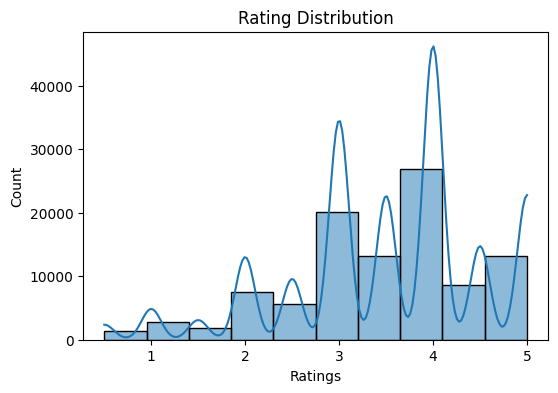


===== Regression Results =====
RMSE: 1.047872279127166
R2 Score: 0.0018222242743777262


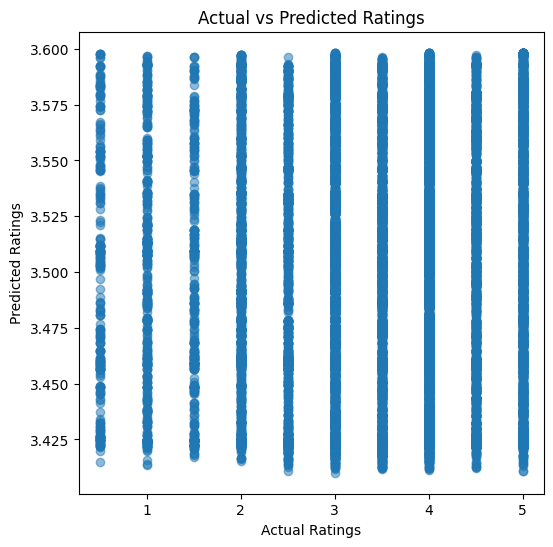


===== Classification Results =====
Accuracy: 0.6118107893692979

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00      7829
           1       0.61      1.00      0.76     12339

    accuracy                           0.61     20168
   macro avg       0.31      0.50      0.38     20168
weighted avg       0.37      0.61      0.46     20168



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


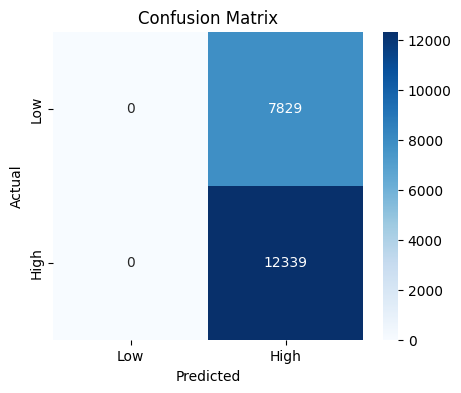


Sample Predictions:
       userId  movieId  Actual Rating  Predicted Rating
67037     432    77866            4.5          3.468019
42175     288      474            3.0          3.515040
93850     599     4351            3.0          3.424625
6187       42     2987            4.0          3.586178
12229      75     1610            4.0          3.576706
7433       51      177            4.0          3.583761
53802     354    51662            3.5          3.492417
65098     416      750            4.5          3.477917
68041     438     6503            0.5          3.471148
11854      73     8641            3.5          3.576806


In [2]:
# ==========================================
# Experiment 08: Movie Recommendation System
# ==========================================

# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. Load Dataset
ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

# 3. Merge Datasets
df = pd.merge(ratings, movies, on='movieId')

print("Merged Dataset Preview:")
print(df.head())

# ==========================================
# 🔹 Rating Distribution (NEW)
# ==========================================

plt.figure(figsize=(6,4))
sns.histplot(df['rating'], bins=10, kde=True)
plt.title("Rating Distribution")
plt.xlabel("Ratings")
plt.ylabel("Count")
plt.show()

# ==========================================
# 🔹 REGRESSION MODEL
# ==========================================

X = df[['userId', 'movieId']]
y = df['rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

y_pred = reg_model.predict(X_test)

print("\n===== Regression Results =====")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

# Scatter Plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings")
plt.show()

# ==========================================
# 🔹 CLASSIFICATION MODEL
# ==========================================

# Convert rating → class
def rating_to_class(r):
    return 1 if r >= 3.5 else 0

df['rating_class'] = df['rating'].apply(rating_to_class)

X_c = df[['userId', 'movieId']]
y_c = df['rating_class']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42
)

clf_model = LinearRegression()
clf_model.fit(X_train_c, y_train_c)

y_pred_c = clf_model.predict(X_test_c)
y_pred_c = [1 if i >= 0.5 else 0 for i in y_pred_c]

print("\n===== Classification Results =====")
print("Accuracy:", accuracy_score(y_test_c, y_pred_c))
print("\nClassification Report:\n", classification_report(y_test_c, y_pred_c))

# ==========================================
# 🔹 Confusion Matrix (IMPROVED)
# ==========================================

cm = confusion_matrix(y_test_c, y_pred_c)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Low", "High"],
            yticklabels=["Low", "High"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==========================================
# 🔹 Sample Predictions
# ==========================================

results = X_test.copy()
results['Actual Rating'] = y_test
results['Predicted Rating'] = y_pred

print("\nSample Predictions:")
print(results.head(10))